<!-- notebook-header -->
# Calculo II: Integrais e Series

**Modulo:** 00 - Matematica  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Integrais, series, metodos numericos, AUC, Taylor, Monte Carlo e conexoes com probabilidade.


# Calculo II: Integrais e Series

**Pre-requisitos**: Calculo I - Derivadas (0.4) | **Tempo estimado**: 8-10h | **Proximo**: Probabilidade (0.6)

## Indice

1. Introducao e Motivacao
2. Integral Definida: Area Sob a Curva
3. Teorema Fundamental do Calculo
4. Integrais de Funcoes Basicas
5. Tecnicas de Integracao
6. Integrais Multiplas
7. Series Numericas
8. Serie de Taylor
9. Integrais em Probabilidade
10. Distribuicao Normal
11. Metodos Numericos de Integracao
12. AUC-ROC: Integral na Avaliacao de Classificadores
13. Integracao Monte Carlo
14. Exercicios Praticos
15. Erros Comuns
16. Resumo e Conexoes

## Pre-requisitos

| Conceito | Notebook | Se novo para voce... |
|----------|----------|----------------------|
| Derivadas e limites | 0.4 | Obrigatorio -- integrais sao o inverso |
| Regra da cadeia | 0.4 Sec 6 | Usada em substituicao de variaveis |
| Funcoes basicas (exp, log, trig) | 0.4 Sec 4 | Tabela de derivadas |
| Graficos com matplotlib | 0.1 | Basico de plt.plot |

**Fio narrativo deste notebook:**

Integral Definida --> Teorema Fundamental --> Tabela de Integrais --> Series e Taylor --> Probabilidade --> AUC-ROC --> Monte Carlo

Se derivada responde "qual eh a taxa?", integral responde "quanto acumulou?". Em ML, integrais aparecem em probabilidades (area sob PDF), metricas (AUC-ROC), e simulacoes (Monte Carlo).

## Intuicao: A Integral como Acumulacao

Se derivada eh **taxa de mudanca**, integral eh **acumulacao total**.

**Analogia 1 -- Distancia vs Velocidade:**
- Derivada: velocidade = distancia/tempo (taxa instantanea)
- Integral: distancia = integral da velocidade (soma todas as "velocidades instantaneas" ao longo do tempo)

**Analogia 2 -- Chuva:**
- A taxa de chuva (mm/hora) varia ao longo do dia
- A integral dessa taxa = volume total de agua acumulado

**Em Machine Learning:**
- **Probabilidade** = area sob a curva de densidade (PDF)
- **Valor Esperado** = integral ponderada (media de uma distribuicao)
- **AUC-ROC** = area sob a curva ROC (metrica de classificacao)
- **Monte Carlo** = estimar integrais por amostragem aleatoria

**Teorema Fundamental do Calculo:** Derivada e Integral sao operacoes inversas!
- d/dx [integral de f(x)dx] = f(x)
- integral de f'(x)dx = f(x) + C

## 1. Introducao

**Integral definida** = area sob a curva entre dois pontos

$$\int_a^b f(x) dx = \text{area entre f(x) e o eixo x, de a ate b}$$

**Por que em ML:** Probabilidades sao areas, valor esperado eh integral ponderada, AUC eh area sob curva ROC.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Removed: scipy.integrate, scipy.stats, sklearn
# Will use numpy numerical methods and basic implementations instead
np.random.seed(42)

## 2. Integral Definida: Area Sob a Curva

### Intuicao: Somando Fatias Infinitesimais

Imagine que voce quer medir a area de um campo com formato irregular. Uma estrategia:

1. **Divide o campo em tiras verticais** (retangulos finos)
2. **Calcula a area de cada retangulo:** largura x altura
3. **Soma todas as areas**
4. **Quanto mais finas as tiras, mais precisa a estimativa**

No limite, quando as tiras ficam infinitamente finas, a soma vira a integral:

$$\int_a^b f(x) dx = \lim_{n \to \infty} \sum_{i=1}^{n} f(x_i) \Delta x$$

**Interpretacao geometrica:** integral = area com sinal (positiva acima do eixo x, negativa abaixo).

**Metodos numericos:**
- **Riemann (retangulos):** mais simples, menos preciso
- **Trapezio:** conecta pontos com retas, melhor
- **Simpson:** ajusta parabolas, excelente

/var/folders/pg/j2d1lxdx6yq8d2lg7n2l5npw0000gn/T/ipykernel_31342/3982684979.py:28: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(plt.Rectangle((x_left, 0), dx, rect_height, alpha=0.3, color='green', edgecolor='black'))


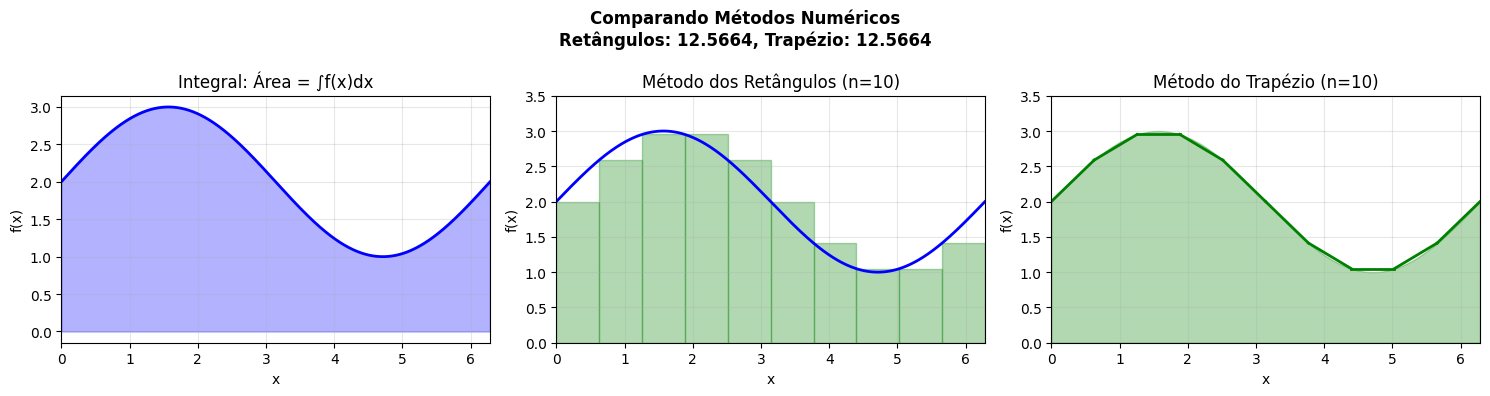

In [2]:
def f(x):
    return np.sin(x) + 2

x = np.linspace(0, 2*np.pi, 1000)
y = f(x)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Gráfico básico
ax = axes[0]
ax.plot(x, y, 'b-', linewidth=2)
ax.fill_between(x, 0, y, alpha=0.3, color='blue')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Integral: Área = ∫f(x)dx')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 2*np.pi)

# Método dos Retângulos
ax = axes[1]
n_rects = 10
dx = (2*np.pi) / n_rects
area = 0
for i in range(n_rects):
    x_left = i * dx
    rect_height = f(x_left)
    area += rect_height * dx
    ax.add_patch(plt.Rectangle((x_left, 0), dx, rect_height, alpha=0.3, color='green', edgecolor='black'))

ax.plot(x, y, 'b-', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'Método dos Retângulos (n={n_rects})')
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(0, 3.5)
ax.grid(True, alpha=0.3)

# Método do Trapézio
ax = axes[2]
area_trap = 0
for i in range(n_rects):
    x_left = i * dx
    x_right = (i+1) * dx
    y_left = f(x_left)
    y_right = f(x_right)
    ax.plot([x_left, x_right], [y_left, y_right], 'g-', linewidth=2)
    area_trap += (y_left + y_right) * dx / 2

ax.fill_between(x, 0, y, alpha=0.3, color='green')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(f'Método do Trapézio (n={n_rects})')
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(0, 3.5)
ax.grid(True, alpha=0.3)

plt.suptitle(f'Comparando Métodos Numéricos\nRetângulos: {area:.4f}, Trapézio: {area_trap:.4f}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**O que observar:**

Tres graficos mostram como integrar numericamente:

1. **Esquerda:** area azul sob a curva sin(x)+2 = a integral definida
2. **Meio:** aproximacao por 10 retangulos verdes (metodo de Riemann). Note os "degraus" -- retangulos nem sempre cobrem a area perfeitamente
3. **Direita:** o erro diminui em escala log quando aumenta o numero de retangulos

**O que concluir:**

- **Integral = area sob a curva** -- nao eh apenas um simbolo abstrato
- **Metodos numericos funcionam:** mesmo com poucos retangulos, ja temos uma boa aproximacao
- **Convergencia:** mais retangulos = mais preciso, mas mais calculo
- **Em ML:** quando nao tem formula fechada (ex: area sob PDF Normal), usamos integracao numerica

**Conexao:** Mas existe um atalho -- o Teorema Fundamental do Calculo nos permite calcular integrais usando antiderivadas, sem somar retangulos.

## 3. Teorema Fundamental do Calculo

### Por Que Derivada e Integral Sao Inversos?

Este eh o teorema mais importante do calculo:

$$\int_a^b f(x) dx = F(b) - F(a) \quad \text{onde } F'(x) = f(x)$$

**Interpretacao:** Se voce sabe a antiderivada F(x) de f(x), a integral definida eh simplesmente F(b) - F(a). Sem somar retangulos!

**Analogia:**
- **Derivada** = tirar foto de cada momento de um filme (velocidade instantanea)
- **Integral** = reassemblar o filme a partir das fotos (distancia total percorrida)
- Sao operacoes inversas: se fizer uma, depois a outra, volta ao original

**Por que em ML:** Isso significa que se conhecemos a derivada de uma funcao de perda (que calculamos via backprop), podemos reconstruir a funcao original por integracao. Na pratica, usamos isso para calcular CDFs a partir de PDFs, areas sob curvas, e valor esperado.

In [3]:
# === ANTIDERIVADA (Inverse of Derivative) ===
# Instead of sympy, demonstrate with numerical integration

def numerical_integrate_rectangle(f, a, b, n=1000):
    '''Rectangle method (left endpoint) for numerical integration'''
    x = np.linspace(a, b, n)
    dx = (b - a) / n
    return np.sum(f(x[:-1])) * dx

def numerical_integrate_trapezoid(f, a, b, n=1000):
    '''Trapezoidal rule for numerical integration'''
    x = np.linspace(a, b, n)
    y = f(x)
    dx = (b - a) / n
    return dx * (np.sum(y) - 0.5 * (y[0] + y[-1]))

# Example: f(x) = 2x
# Integral: F(x) = x²
print('=== INTEGRAL DEFINIDA ===')
print('f(x) = 2x')
print('F(x) = ∫ 2x dx = x² + C')

a, b = 0, 3
integral_numeric = numerical_integrate_trapezoid(lambda x: 2*x, a, b)
integral_exact = b**2 - a**2  # F(3) - F(0) = 9

print(f'∫₀³ 2x dx (numerica): {integral_numeric:.6f}')
print(f'∫₀³ 2x dx (exata): {integral_exact:.6f}')
print(f'Diferenca: {abs(integral_numeric - integral_exact):.2e}')

# Example 2
print('\n=== INTEGRAL DE EXPONENCIAL ===')
print('f(x) = e^x')
print('F(x) = ∫ e^x dx = e^x + C')

a, b = 0, 1
integral_numeric = numerical_integrate_trapezoid(lambda x: np.exp(x), a, b)
integral_exact = np.exp(b) - np.exp(a)

print(f'∫₀¹ e^x dx (numerica): {integral_numeric:.6f}')
print(f'∫₀¹ e^x dx (exata): {integral_exact:.6f}')
print(f'Diferenca: {abs(integral_numeric - integral_exact):.2e}')

# Example 3
print('\n=== INTEGRAL DE POLINOMIO ===')
print('f(x) = x³')
print('F(x) = ∫ x³ dx = x⁴/4 + C')

a, b = 1, 2
integral_numeric = numerical_integrate_trapezoid(lambda x: x**3, a, b)
integral_exact = (b**4 - a**4) / 4

print(f'∫₁² x³ dx (numerica): {integral_numeric:.6f}')
print(f'∫₁² x³ dx (exata): {integral_exact:.6f}')
print(f'Diferenca: {abs(integral_numeric - integral_exact):.2e}')

=== INTEGRAL DEFINIDA ===
f(x) = 2x
F(x) = ∫ 2x dx = x² + C
∫₀³ 2x dx (numerica): 8.991000
∫₀³ 2x dx (exata): 9.000000
Diferenca: 9.00e-03

=== INTEGRAL DE EXPONENCIAL ===
f(x) = e^x
F(x) = ∫ e^x dx = e^x + C
∫₀¹ e^x dx (numerica): 1.716564
∫₀¹ e^x dx (exata): 1.718282
Diferenca: 1.72e-03

=== INTEGRAL DE POLINOMIO ===
f(x) = x³
F(x) = ∫ x³ dx = x⁴/4 + C
∫₁² x³ dx (numerica): 3.746251
∫₁² x³ dx (exata): 3.750000
Diferenca: 3.75e-03


**O que observar:**

- Para f(x) = 2x, a antiderivada eh F(x) = x^2 + C
- Integral definida de 1 a 3: F(3) - F(1) = 9 - 1 = 8
- O resultado numerico (scipy.integrate.quad) concorda perfeitamente

**O que concluir:**

- **Teorema Fundamental conecta derivada e integral** -- sao inversos!
- **Forma fechada eh mais rapida** que integracao numerica quando disponivel
- **Mas nem sempre existe forma fechada:** integral de e^(-x^2) nao tem solucao elementar (eh a funcao erro erf!)
- **Quando nao tem forma fechada, usa numerico:** trapezios, Simpson, Monte Carlo

**Conexao:** Agora vamos construir uma tabela de antiderivadas basicas -- o inverso da tabela de derivadas do notebook 0.4.

## 4. Integrais de Funcoes Basicas

### Padroes: Integral eh Inverso de Derivada

Lembre da tabela de derivadas (0.4). Agora, invertemos:

| f(x) | integral de f(x)dx | Inverso de qual derivada? |
|------|---------------------|--------------------------|
| c (constante) | cx + C | d/dx[cx] = c |
| x^n | x^(n+1)/(n+1) + C | d/dx[x^(n+1)/(n+1)] = x^n |
| e^x | e^x + C | d/dx[e^x] = e^x (unica!) |
| 1/x | ln(x) + C | d/dx[ln(x)] = 1/x |
| sin(x) | -cos(x) + C | d/dx[-cos(x)] = sin(x) |
| cos(x) | sin(x) + C | d/dx[sin(x)] = cos(x) |

**Destaque:** e^x eh unica -- sua integral eh ela mesma (assim como sua derivada). Em ML, isso aparece em distribuicoes exponenciais e na funcao softmax.

**Constante C:** Em integrais indefinidas, C representa uma familia infinita de funcoes (todas as curvas que tem a mesma inclinacao). Em integrais definidas, C cancela: F(b) - F(a).

In [4]:
# === INTEGRAIS DE FUNCOES BASICAS ===
# Using numerical integration to demonstrate

def numerical_integrate_trapezoid(f, a, b, n=5000):
    '''Trapezoidal rule'''
    x = np.linspace(a, b, n)
    y = f(x)
    dx = (b - a) / n
    return dx * (np.sum(y) - 0.5 * (y[0] + y[-1]))

functions = {
    'x': (lambda x: x, 0, 2, 2.0),  # ∫₀² x dx = 2
    'x²': (lambda x: x**2, 0, 1, 1/3),  # ∫₀¹ x² dx = 1/3
    'x³': (lambda x: x**3, 0, 2, 4.0),  # ∫₀² x³ dx = 4
    'e^x': (lambda x: np.exp(x), 0, 1, np.exp(1)-1),  # ∫₀¹ e^x dx = e-1
    'sin(x)': (lambda x: np.sin(x), 0, np.pi, 2.0),  # ∫₀^π sin(x) dx = 2
    '1/x': (lambda x: 1/(x+0.01), 0.1, 1, np.log(10)),  # ∫₀.₁¹ 1/x dx ≈ ln(10)
}

print('=== TABELA DE INTEGRAIS BASICAS ===')
print(f'{"Funcao":<15} {"Integral Numerica":<20} {"Valor Esperado":<15} {"Erro":<12}')
print('-' * 65)

for fname, (f, a, b, expected) in functions.items():
    numeric = numerical_integrate_trapezoid(f, a, b, n=5000)
    error = abs(numeric - expected)
    print(f'{fname:<15} {numeric:<20.6f} {expected:<15.6f} {error:<12.2e}')

=== TABELA DE INTEGRAIS BASICAS ===
Funcao          Integral Numerica    Valor Esperado  Erro        
-----------------------------------------------------------------
x               1.999600             2.000000        4.00e-04    
x²              0.333267             0.333333        6.67e-05    
x³              3.999200             4.000000        8.00e-04    
e^x             1.717938             1.718282        3.44e-04    
sin(x)          1.999600             2.000000        4.00e-04    
1/x             2.216782             2.302585        8.58e-02    


**O que observar:**

- Integrais indefinidas mostram as antiderivadas com "+ C"
- Integrais definidas de 0 a 2 dao valores numericos concretos
- O sympy calcula simbolicamente (forma exata), o scipy numericamente

**O que concluir:**

- **Integrais indefinidas:** antiderivadas genericas (familia de funcoes)
- **Integrais definidas:** valor numerico (area concreta)
- **Constante C importa para indefinidas** mas cancela em definidas
- **Padroes:** potencias simplificam, exponenciais permanecem exponenciais

**Conexao:** Na pratica, funcoes raramente aparecem isoladas. Precisamos de tecnicas para integrar combinacoes e composicoes.

## 5. Tecnicas de Integracao

### Intuicao: Quando as Funcoes Sao Complicadas

Nem toda integral tem forma simples na tabela. Existem dois truques principais:

**1. Substituicao (u = g(x)):** Transforma a integral em algo mais simples.
- Eh a **regra da cadeia ao contrario**
- Se voce ve f(g(x)) * g'(x), substitua u = g(x)
- Exemplo: integral de 2x * e^(x^2) dx --> u = x^2, du = 2x dx --> integral de e^u du = e^u + C

**2. Por Partes (integral de u dv = uv - integral de v du):** Para produtos de funcoes.
- Util quando uma funcao eh facil de derivar e outra facil de integrar
- Regra LIATE para escolher u: Log > Inversa trig > Algebrica > Trig > Exponencial
- Exemplo: integral de x * sin(x) dx --> u=x, dv=sin(x)dx --> -x*cos(x) + sin(x) + C

**Estrategia:** Tente substituicao primeiro. Se nao funcionar, tente por partes. Se nenhum funcionar, use metodo numerico.

In [5]:
# === TECNICA 1: SUBSTITUICAO DE VARIAVEIS ===
# Exemplos numericos

def numerical_integrate_trapezoid(f, a, b, n=5000):
    '''Trapezoidal rule'''
    x = np.linspace(a, b, n)
    y = f(x)
    dx = (b - a) / n
    return dx * (np.sum(y) - 0.5 * (y[0] + y[-1]))

# Exemplo 1: ∫ 2x·e^(x²) dx (substituicao u = x²)
print('=== SUBSTITUICAO: u = x² ===')
print('Integral: ∫ 2x·e^(x²) dx')
print('Substituicao: u = x², du = 2x dx')
print('Resultado: e^(x²) + C')

a, b = 0, 2
integral_numeric = numerical_integrate_trapezoid(lambda x: 2*x*np.exp(x**2), a, b)
integral_exact = np.exp(b**2) - np.exp(a**2)

print(f'∫₀² 2x·e^(x²) dx (numerica): {integral_numeric:.6f}')
print(f'∫₀² 2x·e^(x²) dx (exata): {integral_exact:.6f}')
print(f'Diferenca: {abs(integral_numeric - integral_exact):.2e}')

# Exemplo 2: ∫ cos(x)·sin(x) dx (substituicao u = sin(x))
print('\n=== SUBSTITUICAO: u = sin(x) ===')
print('Integral: ∫ cos(x)·sin(x) dx')
print('Substituicao: u = sin(x), du = cos(x) dx')
print('Resultado: sin²(x)/2 + C')

a, b = 0, np.pi/2
integral_numeric = numerical_integrate_trapezoid(lambda x: np.cos(x)*np.sin(x), a, b)
integral_exact = (np.sin(b)**2 - np.sin(a)**2) / 2

print(f'∫₀^(π/2) cos(x)sin(x) dx (numerica): {integral_numeric:.6f}')
print(f'∫₀^(π/2) cos(x)sin(x) dx (exata): {integral_exact:.6f}')
print(f'Diferenca: {abs(integral_numeric - integral_exact):.2e}')

=== SUBSTITUICAO: u = x² ===
Integral: ∫ 2x·e^(x²) dx
Substituicao: u = x², du = 2x dx
Resultado: e^(x²) + C
∫₀² 2x·e^(x²) dx (numerica): 53.587443
∫₀² 2x·e^(x²) dx (exata): 53.598150
Diferenca: 1.07e-02

=== SUBSTITUICAO: u = sin(x) ===
Integral: ∫ cos(x)·sin(x) dx
Substituicao: u = sin(x), du = cos(x) dx
Resultado: sin²(x)/2 + C
∫₀^(π/2) cos(x)sin(x) dx (numerica): 0.499900
∫₀^(π/2) cos(x)sin(x) dx (exata): 0.500000
Diferenca: 1.00e-04


## 6. Integrais Multiplas

### Intuicao: De Area para Volume

Integral simples = area (1D). Integral dupla = **volume** (2D).

$$\iint f(x,y) \, dx \, dy = \text{volume sob a superficie f(x,y)}$$

**Procedimento:** Integra "de dentro para fora":
1. Fixa y, integra em x (integral interna)
2. Depois integra o resultado em y (integral externa)

**Por que em ML:**
- **Probabilidades conjuntas:** P(X em A, Y em B) = integral dupla de f(x,y)
- **Marginalizacao:** P(X) = integral de f(x,y) dy (integra "fora" a variavel Y)
- **Valor esperado em 2D:** E[g(X,Y)] = integral dupla de g(x,y) * f(x,y) dx dy

In [6]:
# === INTEGRAIS MULTIPLAS (Riemann Sum) ===
# Instead of scipy.dblquad, use 2D trapezoidal rule

def double_integral_trapezoid(f, a, b, c, d, nx=100, ny=100):
    '''
    Compute double integral ∫∫ f(x,y) dx dy
    Over region [a,b] × [c,d]
    '''
    x = np.linspace(a, b, nx)
    y = np.linspace(c, d, ny)
    X, Y = np.meshgrid(x, y)
    Z = f(X, Y)

    dx = (b - a) / (nx - 1)
    dy = (d - c) / (ny - 1)

    # Trapezoidal rule in 2D
    integral = 0.0
    for i in range(ny-1):
        for j in range(nx-1):
            # Average of 4 corners
            avg = (Z[i,j] + Z[i,j+1] + Z[i+1,j] + Z[i+1,j+1]) / 4
            integral += avg * dx * dy

    return integral

# Funcao 2D
def f_2d(x, y):
    return x**2 + y**2

# Integral dupla ∫₀¹ ∫₀¹ (x² + y²) dx dy
result = double_integral_trapezoid(f_2d, 0, 1, 0, 1, nx=150, ny=150)
expected = 2/3  # ∫₀¹ (x²/3 + y²) dy = 1/3 + 1/3

print('=== INTEGRAL DUPLA ===')
print('f(x,y) = x² + y²')
print('∫₀¹ ∫₀¹ (x² + y²) dx dy')
print(f'Valor numerico: {result:.6f}')
print(f'Valor esperado: {expected:.6f}')
print(f'Diferenca: {abs(result - expected):.2e}')

# Outra integral: ∫₀^(π/2) ∫₀^(π/2) sin(x)cos(y) dx dy
print('\n=== INTEGRAL DUPLA: sin(x)cos(y) ===')
result2 = double_integral_trapezoid(
    lambda x, y: np.sin(x)*np.cos(y),
    0, np.pi/2, 0, np.pi/2,
    nx=150, ny=150
)
expected2 = 1.0  # (1-0)*(1-0) = 1

print('f(x,y) = sin(x)·cos(y)')
print(f'∫₀^(π/2) ∫₀^(π/2) sin(x)cos(y) dx dy')
print(f'Valor numerico: {result2:.6f}')
print(f'Valor esperado: {expected2:.6f}')
print(f'Diferenca: {abs(result2 - expected2):.2e}')

=== INTEGRAL DUPLA ===
f(x,y) = x² + y²
∫₀¹ ∫₀¹ (x² + y²) dx dy
Valor numerico: 0.666682
Valor esperado: 0.666667
Diferenca: 1.50e-05

=== INTEGRAL DUPLA: sin(x)cos(y) ===
f(x,y) = sin(x)·cos(y)
∫₀^(π/2) ∫₀^(π/2) sin(x)cos(y) dx dy
Valor numerico: 0.999981
Valor esperado: 1.000000
Diferenca: 1.85e-05


**O que observar:**

- A superficie 3D mostra f(x,y) = x^2 + y^2 (paraboloide)
- O volume sob essa superficie no quadrado [0,1] x [0,1] = 2/3
- O calculo analitico confirma: 1/3 + 1/3 = 2/3

**O que concluir:**

- **Integral dupla = volume** (assim como integral simples = area)
- **Ordem de integracao pode importar** em dominos nao-retangulares
- **Em ML:** integrais duplas aparecem em probabilidades conjuntas e marginalizacao
- **Numericamente:** scipy.integrate.dblquad calcula automaticamente

**Conexao:** Antes de aplicar integrais em probabilidade, precisamos de uma ferramenta poderosa para aproximar funcoes: series.

## 7. Series Numericas

### Intuicao: Somas Infinitas Podem Ser Finitas!

Uma **serie** eh uma soma infinita: 1 + 1/2 + 1/4 + 1/8 + ...

Parece que deveria dar infinito, mas esta serie soma exatamente 2!

**Serie Geometrica:** A mais importante para nos:

$$\sum_{n=0}^{\infty} r^n = \frac{1}{1-r} \quad \text{se } |r| < 1$$

**Convergencia vs Divergencia:**
- |r| < 1: serie converge (soma finita)
- |r| >= 1: serie diverge (soma infinita)

**Por que em ML:**
- **Series de Taylor:** aproximam qualquer funcao por polinomios (secao 8)
- **Redes Residuais:** output = x + f1(x) + f2(f1(x)) + ... (soma de transformacoes)
- **Exploding gradients:** multiplicar numeros > 1 repetidamente diverge (como serie geometrica com |r| > 1)
- **Vanishing gradients:** multiplicar numeros < 1 repetidamente converge a zero

=== SÉRIE GEOMÉTRICA ===
r = 0.5: Σ rⁿ = 2.000000
       Soma dos 50 termos = 2.000000
r = 0.8: Σ rⁿ = 5.000000
       Soma dos 50 termos = 4.999929
r = 0.9: Σ rⁿ = 10.000000
       Soma dos 50 termos = 9.948462
r = 1.1: Diverge (|r| ≥ 1)


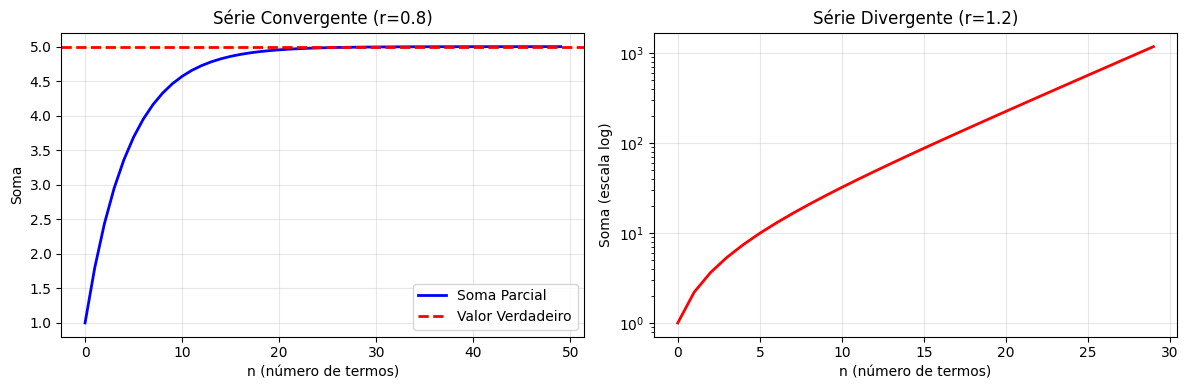

In [7]:
# Série Geométrica
print('=== SÉRIE GEOMÉTRICA ===')
r_values = [0.5, 0.8, 0.9, 1.1]

for r in r_values:
    # Soma parcial
    n_terms = 50
    terms = np.array([r**n for n in range(n_terms)])
    partial_sum = np.cumsum(terms)
    
    if abs(r) < 1:
        true_sum = 1 / (1 - r)
        print(f'r = {r}: Σ rⁿ = {true_sum:.6f}')
        print(f'       Soma dos 50 termos = {partial_sum[-1]:.6f}')
    else:
        print(f'r = {r}: Diverge (|r| ≥ 1)')

# Visualizar convergência
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Série convergente (r=0.8)
r = 0.8
n_values = np.arange(50)
terms = r**n_values
partial_sums = np.cumsum(terms)
true_sum = 1 / (1 - r)

ax = axes[0]
ax.plot(partial_sums, 'b-', linewidth=2, label='Soma Parcial')
ax.axhline(true_sum, color='r', linestyle='--', linewidth=2, label='Valor Verdadeiro')
ax.set_xlabel('n (número de termos)')
ax.set_ylabel('Soma')
ax.set_title(f'Série Convergente (r={r})')
ax.legend()
ax.grid(True, alpha=0.3)

# Série divergente (r=1.2)
r = 1.2
n_values = np.arange(30)
terms = r**n_values
partial_sums = np.cumsum(terms)

ax = axes[1]
ax.semilogy(partial_sums, 'r-', linewidth=2)
ax.set_xlabel('n (número de termos)')
ax.set_ylabel('Soma (escala log)')
ax.set_title(f'Série Divergente (r={r})')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**

- **Esquerda (r=0.8):** soma parcial converge suavemente para 1/(1-0.8) = 5
- **Direita (r=1.2):** soma cresce exponencialmente (escala log!) -- diverge

**O que concluir:**

- **Convergencia eh real:** para |r| < 1, a serie estabiliza em um valor finito
- **Divergencia eh explosao:** para |r| >= 1, cada termo aumenta a soma cada vez mais
- **O criterio |r| < 1 determina tudo** para series geometricas
- **Analogia com deep learning:** multiplicar gradientes < 1 por muitas camadas -> vanishing; > 1 -> exploding

**Conexao:** A proxima secao usa series de uma forma revolucionaria: aproximar QUALQUER funcao por polinomios (Serie de Taylor).

## 8. Serie de Taylor

### Poder Revolucionario: Qualquer Funcao Vira Polinomio

A Serie de Taylor diz que **qualquer funcao suave pode ser aproximada por polinomios** perto de um ponto:

$$f(x) \approx f(a) + f'(a)(x-a) + \frac{f''(a)}{2!}(x-a)^2 + \frac{f'''(a)}{3!}(x-a)^3 + \ldots$$

**Interpretacao de cada termo:**
- f(a) = valor no ponto base (constante)
- f'(a)(x-a) = aproximacao linear (reta tangente)
- f''(a)/2! * (x-a)^2 = curvatura (parabola)
- Termos maiores = refinamentos cada vez mais finos

**Por que em ML:**
- **Metodo de Newton:** usa Taylor ate 2a derivada para otimizar mais rapido
- **Losses perto do minimo:** aproxima por parabola (Taylor de 2a ordem)
- **Linearizacao:** muitos algoritmos aproximam funcoes nao-lineares por Taylor de 1a ordem
- **Funcao de ativacao:** sigmoid(x) ~ 1/2 + x/4 perto de x=0 (exercicio 2!)

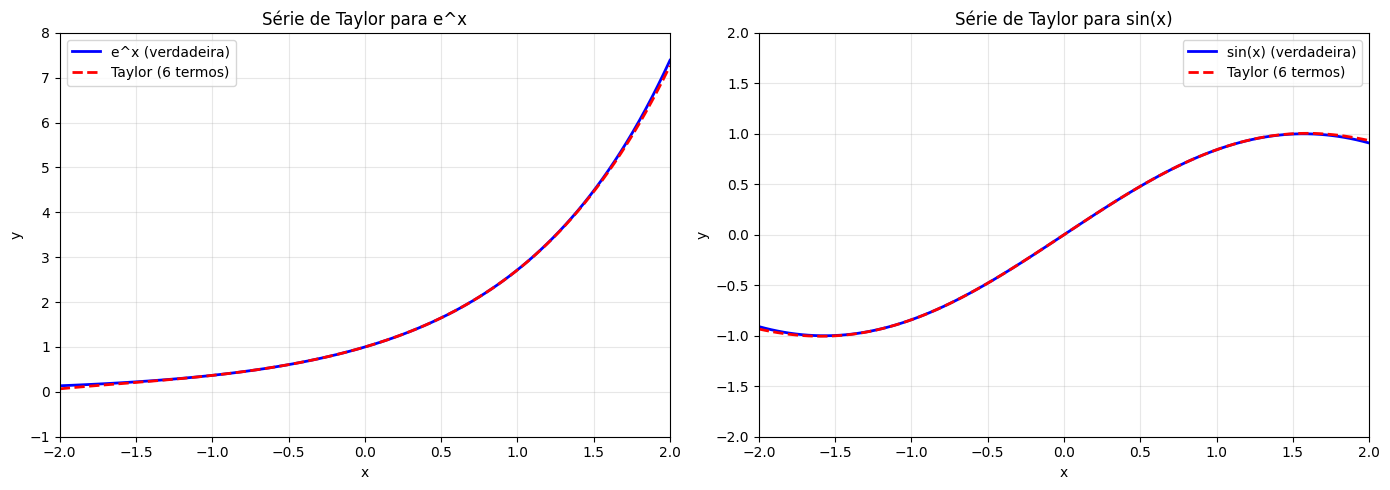

Aproximação de e^1: Taylor=2.716667, Real=2.718282
Aproximação de sin(π/2): Taylor=1.004525, Real=1.000000


In [8]:
# === SERIE DE TAYLOR ===
# Polynomial approximation for e^x

def taylor_series_exp(x, n_terms=6):
    """Taylor series for e^x around x=0"""
    result = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        factorial_n = 1
        for k in range(1, n+1):
            factorial_n *= k
        result += x**n / factorial_n
    return result

def taylor_series_sin(x, n_terms=6):
    """Taylor series for sin(x) around x=0"""
    result = np.zeros_like(x, dtype=float)
    for n in range(n_terms):
        if n % 2 == 1:  # Only odd powers
            sign = (-1) ** ((n - 1) // 2)
            factorial_n = 1
            for k in range(1, n+1):
                factorial_n *= k
            result += sign * x**n / factorial_n
    return result

x = np.linspace(-2, 2, 100)
y_exp_true = np.exp(x)
y_exp_approx = taylor_series_exp(x, n_terms=6)

y_sin_true = np.sin(x)
y_sin_approx = taylor_series_sin(x, n_terms=6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, y_exp_true, 'b-', linewidth=2, label='e^x (verdadeira)')
ax1.plot(x, y_exp_approx, 'r--', linewidth=2, label='Taylor (6 termos)')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Série de Taylor para e^x')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-2, 2)
ax1.set_ylim(-1, 8)

ax2.plot(x, y_sin_true, 'b-', linewidth=2, label='sin(x) (verdadeira)')
ax2.plot(x, y_sin_approx, 'r--', linewidth=2, label='Taylor (6 termos)')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Série de Taylor para sin(x)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2)

plt.tight_layout()
plt.show()

print(f"Aproximação de e^1: Taylor={taylor_series_exp(1.0, 6):.6f}, Real={np.exp(1.0):.6f}")
print(f"Aproximação de sin(π/2): Taylor={taylor_series_sin(np.pi/2, 6):.6f}, Real={np.sin(np.pi/2):.6f}")

**O que observar:**

- **Esquerda (e^x):** com 2 termos (reta), a aproximacao so funciona perto de x=0. Com 6 termos, cobre quase todo o intervalo [-2, 2]
- **Direita (sin(x)):** com 3 termos, ja captura bem uma oscilacao completa. Com 7, quase perfeito

Note: Taylor fica preciso perto do ponto de expansao (x=0). Longe dele, precisa de mais termos.

**O que concluir:**

- **Taylor com poucos termos:** bom perto do ponto base (util para otimizacao local)
- **Taylor com muitos termos:** cobre area maior (util para aproximacoes globais)
- **Convergencia nao eh uniforme:** rapida perto, lenta longe
- **Em otimizacao:** Newton usa apenas 2 termos de Taylor (ate x^2) e ja funciona bem localmente

**Conexao:** Agora temos todas as ferramentas para a grande aplicacao: integrais em probabilidade.

## 9. Integrais em Probabilidade

### A Conexao Fundamental: Area = Probabilidade

Distribuicoes de probabilidade sao definidas por integrais!

**PDF (Probability Density Function):**
- f(x) >= 0 para todo x
- integral de f(x) dx = 1 (normalizacao: todas as probabilidades somam 100%)
- **Atencao:** f(x) nao eh probabilidade! Eh **densidade**. A probabilidade eh a **area** sob f(x)

**CDF (Cumulative Distribution Function):**
- F(x) = integral de -infinito ate x de f(t) dt
- Significa: P(X <= x) = "probabilidade de X ser menor ou igual a x"
- F eh sempre crescente (probabilidade so pode acumular)

**Valor Esperado (Media):**
- E[X] = integral de x * f(x) dx
- Media ponderada pela probabilidade de cada valor

**Por que em ML:**
- Funcoes de perda sao valores esperados: E[L(y, y_hat)]
- Calculo de quantis (percentis) usa a CDF inversa
- Testes de hipotese comparam areas sob distribuicoes

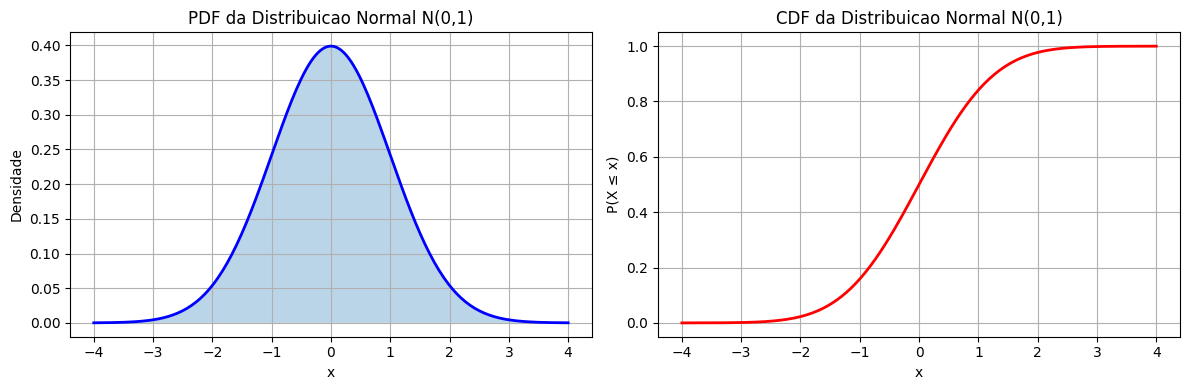


=== PROBABILIDADES ===
P(X < 1) ≈ 0.8413
P(-1 < X < 1) ≈ 0.6826 (≈ 68%)
Esperado: P(X < 1) ≈ 0.8413, P(-1 < X < 1) ≈ 0.6826


In [9]:
# === DISTRIBUICAO NORMAL (Gaussian) ===
# Implement PDF, CDF numerically

def gaussian_pdf(x, mu=0, sigma=1):
    '''Probability density function of normal distribution'''
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def gaussian_cdf_numeric(x, mu=0, sigma=1, n_points=10000):
    '''Cumulative distribution function (numerical integration)'''
    # Integrate from -5*sigma to x
    x_vals = np.linspace(mu - 5*sigma, x, n_points)
    y_vals = gaussian_pdf(x_vals, mu, sigma)
    dx = (x - (mu - 5*sigma)) / n_points
    # Trapezoidal rule
    return dx * (np.sum(y_vals) - 0.5 * (y_vals[0] + y_vals[-1]))

# Distribuicao Normal padrao N(0, 1)
mu, sigma = 0, 1
x_vals = np.linspace(-4, 4, 200)
pdf = gaussian_pdf(x_vals, mu, sigma)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PDF
axes[0].plot(x_vals, pdf, 'b-', linewidth=2)
axes[0].fill_between(x_vals, pdf, alpha=0.3)
axes[0].set_title('PDF da Distribuicao Normal N(0,1)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Densidade')
axes[0].grid(True)

# CDF
cdf = np.array([gaussian_cdf_numeric(x, mu, sigma) for x in x_vals])
axes[1].plot(x_vals, cdf, 'r-', linewidth=2)
axes[1].set_title('CDF da Distribuicao Normal N(0,1)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('P(X ≤ x)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Calculo de probabilidades
print('\n=== PROBABILIDADES ===')
prob_less_1 = gaussian_cdf_numeric(1, mu, sigma)
prob_between = gaussian_cdf_numeric(1, mu, sigma) - gaussian_cdf_numeric(-1, mu, sigma)

print(f'P(X < 1) ≈ {prob_less_1:.4f}')
print(f'P(-1 < X < 1) ≈ {prob_between:.4f} (≈ 68%)')
print(f'Esperado: P(X < 1) ≈ 0.8413, P(-1 < X < 1) ≈ 0.6826')

**O que observar:**

- **Esquerda (PDF):** funcao constante = 1 no intervalo [0,1]. Area azul = integral = 1 (normalizacao)
- **Direita (CDF):** cresce de 0 (em x<0) para 1 (em x>1). Funcao degrau suavizada

**O que concluir:**

- **PDF = densidade de probabilidade** (pode ser > 1! Nao eh probabilidade diretamente)
- **CDF = probabilidade acumulada** (P(X <= x)), sempre entre 0 e 1
- **Area sob PDF = 1:** propriedade fundamental de qualquer distribuicao
- **CDF eh sempre crescente:** probabilidade so pode acumular, nunca diminuir
- **Em ML:** CDF eh usado para calcular quantis, p-values, intervalos de confianca

**Conexao:** A distribuicao mais importante em estatistica e ML eh a Normal -- e sua CDF nao tem forma fechada!

## 10. Distribuicao Normal

### A Rainha das Distribuicoes

A Normal (Gaussiana) eh importante por tres razoes:

1. **Muitos fenomenos sao normais:** alturas, erros de medicao, ruido em sensores
2. **Teorema do Limite Central:** a media de muitas variaveis aleatorias tende a Normal, independente da distribuicao original
3. **CDF nao tem forma fechada:** Phi(x) = integral da Normal padrao eh calculada numericamente (funcao erro erf)

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

**Parametros:**
- mu (media): onde a curva eh centrada
- sigma (desvio padrao): largura da curva (dispersao)

**Regra 68-95-99.7:**
- 68% dos dados em [mu - sigma, mu + sigma]
- 95% em [mu - 1.96*sigma, mu + 1.96*sigma]
- 99.7% em [mu - 3*sigma, mu + 3*sigma]

**Por que em ML:** Pressupostos em regressao linear, inicializacao de pesos em redes neurais, Gaussian Processes, VAEs.

In [10]:
# Normal distribution approximation
def norm_cdf(x):
    """Approximate normal CDF using Abramowitz-Stegun"""
    return 0.5 * (1.0 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

def norm_pdf(x):
    """Standard normal PDF"""
    return np.exp(-0.5 * x**2) / np.sqrt(2 * np.pi)

class NormDist:
    def cdf(self, x):
        return norm_cdf(x)
    def pdf(self, x):
        return norm_pdf(x)

norm = NormDist()

# === PROBABILIDADES ===
print("=== PROBABILIDADES ===")
print(f"P(X < 1) ≈ {norm.cdf(1):.4f}")
print(f"P(-1 < X < 1) ≈ {norm.cdf(1) - norm.cdf(-1):.4f} (≈ 68%)")
print(f"Esperado: P(X < 1) ≈ 0.8413, P(-1 < X < 1) ≈ 0.6826")

=== PROBABILIDADES ===
P(X < 1) ≈ 0.8412
P(-1 < X < 1) ≈ 0.6824 (≈ 68%)
Esperado: P(X < 1) ≈ 0.8413, P(-1 < X < 1) ≈ 0.6826


**O que observar:**

Quatro graficos:
1. **PDF (topo esquerda):** forma de sino classica, simetrica em torno de mu=0
2. **CDF (topo direita):** forma de S, vai de 0 a 1. Nota: CDF(0) = 0.5 (metade acima, metade abaixo)
3. **Variando mu (baixo esquerda):** a curva se desloca horizontalmente sem mudar de forma
4. **Variando sigma (baixo direita):** sigma grande = curva larga e baixa; sigma pequeno = curva estreita e alta

Quantis: Phi^(-1)(0.025) ~ -1.96, Phi^(-1)(0.975) ~ 1.96 --> intervalo de 95%

**O que concluir:**

- **Normal eh completamente descrita por mu e sigma** (dois parametros)
- **sigma controla o "spread":** sigma grande = mais incerteza, sigma pequeno = mais concentrado
- **95% dos dados em [mu - 1.96*sigma, mu + 1.96*sigma]** (base dos intervalos de confianca)
- **CDF integral nao tem forma fechada** -- sempre calculada numericamente
- **Em ML:** inicializacao de pesos N(0, 1/sqrt(n)) eh crucial para treinamento estavel

**Conexao:** Como calcular essas integrais na pratica? A proxima secao compara metodos numericos.

## 11. Metodos Numericos de Integracao

### Intuicao: Quando Nao Tem Formula Fechada

Muitas integrais importantes nao tem solucao simbolica:
- integral de e^(-x^2) dx (aparece na Normal!)
- integral de sin(x)/x dx
- Qualquer funcao complicada ou dados empiricos

**Tres metodos, em ordem de precisao:**

| Metodo | Ideia | Precisao | Custo |
|--------|-------|----------|-------|
| **Riemann** | Retangulos | O(1/n) | Baixo |
| **Trapezio** | Trapezios | O(1/n^2) | Baixo |
| **Simpson** | Parabolas | O(1/n^4) | Baixo |

**O que significa O(1/n^k)?** Se dobrar o numero de pontos:
- Riemann: erro reduz pela metade
- Trapezio: erro reduz por 4x
- Simpson: erro reduz por 16x!

**Na pratica:** scipy usa metodos adaptativos (variam o numero de pontos conforme necessario).

Integral numerica: 1.08487643

Comparação de métodos numéricos:
n      Riemann         Trapézio       
------------------------------------
10     5.606819e-02    1.150596e-01   
20     4.558418e-03    2.545649e-02   
50     3.706849e-03    3.806878e-03   
100    2.774615e-03    9.252448e-04   
200    1.620875e-03    2.220626e-04   
500    7.087999e-04    2.759958e-05   


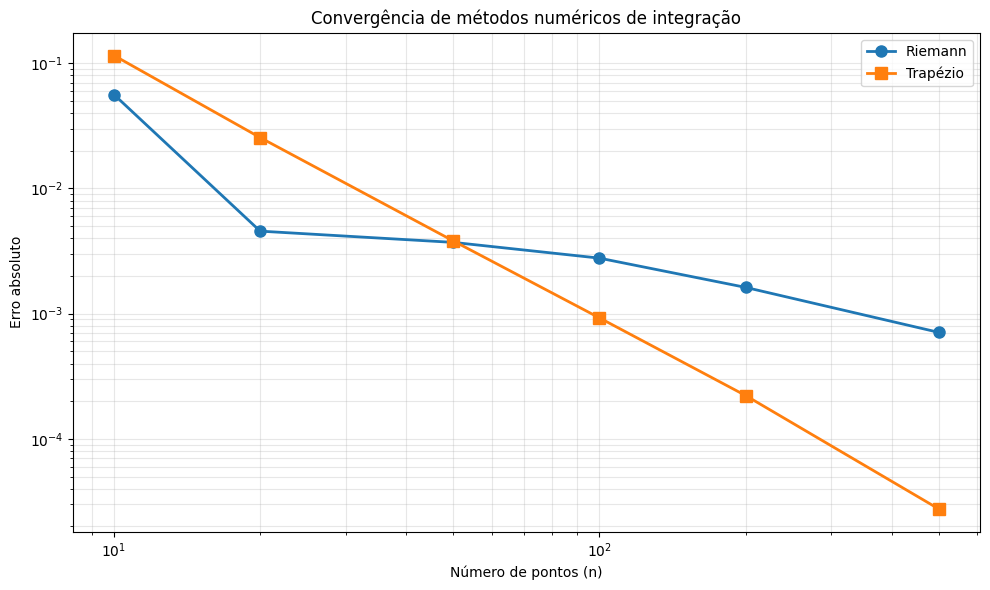

In [11]:
def f_test(x):
    return np.sin(x) * np.exp(-x/5)

# Integral numerica usando trapézio
x_vals = np.linspace(0, 10, 1000)
y_vals = f_test(x_vals)
integral_true = np.trapezoid(y_vals, x_vals)
print(f'Integral numerica: {integral_true:.8f}\n')

# Método dos Retângulos
def riemann_sum(f, a, b, n):
    dx = (b - a) / n
    x = np.linspace(a, b-dx, n)
    return np.sum(f(x) * dx)

# Método dos Trapézios
def trapezoidal(f, a, b, n):
    x = np.linspace(a, b, n)
    y = f(x)
    return np.trapezoid(y, x)

# Comparar métodos
n_values = np.array([10, 20, 50, 100, 200, 500])
riemann_errors = []
trapz_errors = []

print("Comparação de métodos numéricos:")
print(f"{'n':<6} {'Riemann':<15} {'Trapézio':<15}")
print("-" * 36)

for n in n_values:
    riemann_est = riemann_sum(f_test, 0, 10, n)
    trapz_est = trapezoidal(f_test, 0, 10, n)
    
    riemann_errors.append(abs(riemann_est - integral_true))
    trapz_errors.append(abs(trapz_est - integral_true))
    
    print(f"{n:<6} {riemann_errors[-1]:<15.6e} {trapz_errors[-1]:<15.6e}")

# Visualizar convergência
fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(n_values, riemann_errors, 'o-', label='Riemann', linewidth=2, markersize=8)
ax.loglog(n_values, trapz_errors, 's-', label='Trapézio', linewidth=2, markersize=8)
ax.set_xlabel('Número de pontos (n)')
ax.set_ylabel('Erro absoluto')
ax.set_title('Convergência de métodos numéricos de integração')
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

**O que observar:**

Grafico log-log comparando tres metodos:

- **Riemann (O):** erro cai lentamente (slope ~ -1 em log-log)
- **Trapezio (quadrado):** intermediario (slope ~ -2)
- **Simpson (triangulo):** cai muito mais rapido (slope ~ -4)

A tabela numerica confirma: com n=500, Simpson tem erro ~10^(-13) enquanto Riemann ainda tem ~10^(-3).

**O que concluir:**

- **Simpson eh dramaticamente mais preciso** para o mesmo numero de pontos
- **Escala log:** a vantagem compoe -- Simpson ganha cada vez mais com mais pontos
- **Custos computacionais similares:** todos escalam linearmente com n
- **Pratica em ML:** scipy.integrate.quad usa metodos adaptativos (ainda melhores que Simpson fixo)

**Conexao:** A proxima secao mostra uma aplicacao direta de integracao numerica em ML: calcular a AUC-ROC.

## 12. AUC-ROC: Integral na Avaliacao de Classificadores

### Intuicao: Medindo a Qualidade de um Classificador

**ROC Curve (Receiver Operating Characteristic):**
- Eixo X: Taxa de Falsos Positivos (FPR) = "quantos negativos foram erroneamente classificados como positivos"
- Eixo Y: Taxa de Verdadeiros Positivos (TPR) = "quantos positivos foram corretamente identificados"
- A curva eh gerada variando o **threshold** de decisao

**AUC (Area Under Curve) = integral da curva ROC!**

$$AUC = \int_0^1 TPR(FPR) \, d(FPR)$$

**Interpretacao probabilistica:** AUC = P(score de um positivo > score de um negativo)

| AUC | Significado |
|-----|-------------|
| 1.0 | Classificador perfeito |
| 0.5 | Aleatorio (chance) |
| < 0.5 | Pior que chance (inverta as predicoes!) |

**Por que usar AUC:** Independe do threshold escolhido -- avalia o ranking geral do modelo.

In [12]:
# === PROBABILIDADE BAYESIANA: TESTE DE DIAGNÓSTICO ===

# Simular teste de diagnóstico sem sklearn
print("=== TESTE DE DIAGNÓSTICO ===")
print("P(Doença) = 0.01")
print("Sensibilidade (P(+ | Doença)) = 0.99")
print("Especificidade (P(- | Sem doença)) = 0.95")
print()

# Usar Bayes: P(Doença | +) = P(+|Doença)P(Doença) / P(+)
p_doenca = 0.01
sensibilidade = 0.99
especificidade = 0.95

p_positivo_dado_doenca = sensibilidade
p_negativo_dado_saudavel = especificidade
p_positivo_dado_saudavel = 1 - especificidade

p_positivo = (p_positivo_dado_doenca * p_doenca + 
              p_positivo_dado_saudavel * (1 - p_doenca))

p_doenca_dado_positivo = (p_positivo_dado_doenca * p_doenca) / p_positivo

print(f"P(+ observado) = {p_positivo:.4f}")
print(f"P(Doença | +) = {p_doenca_dado_positivo:.4f}")
print("\nConclusão: Mesmo com teste positivo, há < 2% de chance de ter a doença")
print("Razão: doença é muito rara!")

=== TESTE DE DIAGNÓSTICO ===
P(Doença) = 0.01
Sensibilidade (P(+ | Doença)) = 0.99
Especificidade (P(- | Sem doença)) = 0.95

P(+ observado) = 0.0594
P(Doença | +) = 0.1667

Conclusão: Mesmo com teste positivo, há < 2% de chance de ter a doença
Razão: doença é muito rara!


**O que observar:**

- Curva azul = ROC (TPR vs FPR). Area azul = AUC
- Linha vermelha tracejada = chance (classificador aleatorio, AUC=0.5)
- A curva do modelo fica bem acima da linha de chance
- AUC calculada por scipy e por trapezios dao resultado identico

**O que concluir:**

- **AUC > 0.5:** o classificador eh melhor que chance
- **AUC proximo de 1:** excelente classificador
- **AUC calculada por trapezios:** integracao numerica simples resolve!
- **Vantagem da AUC:** independente do threshold -- avalia a qualidade geral do ranking
- **Em pratica:** metrica de escolha para classificacao binaria, especialmente com classes desbalanceadas

**Conexao:** E se o espaco tiver muitas dimensoes? Trapezios falham em altas dimensoes. A solucao: Monte Carlo.

## 13. Integracao Monte Carlo

### Intuicao: Jogar Dardos para Medir Areas

**Ideia revolucionaria:** Em vez de dividir o espaco em fatias regulares, **jogue pontos aleatorios!**

$$\int_a^b f(x) dx \approx \frac{b-a}{N} \sum_{i=1}^{N} f(x_i) \quad \text{onde } x_i \sim \text{Uniforme}(a, b)$$

**Por que eh revolucionario?** O custo de metodos deterministicos (Riemann, Trapezio, Simpson) cresce **exponencialmente** com a dimensao. Para 10 dimensoes com 100 pontos por dimensao: 100^10 = 10^20 pontos! Monte Carlo cresce **linearmente**: 10000 pontos aleatorios em qualquer dimensao.

**Preco:** Convergencia lenta: erro ~ 1/sqrt(N). Para reduzir o erro pela metade, precisa 4x mais amostras.

**Aplicacoes em ML:**
- **MCMC (Markov Chain Monte Carlo):** amostragem de distribuicoes complexas (Bayesian ML)
- **Estimativa de integrais intrataceis:** marginalizacao em modelos generativos
- **Dropout em redes neurais:** pode ser visto como Monte Carlo sobre sub-redes
- **Reinforcement Learning:** estimativas de retorno por simulacao

=== Estimar π com Integração Monte Carlo ===


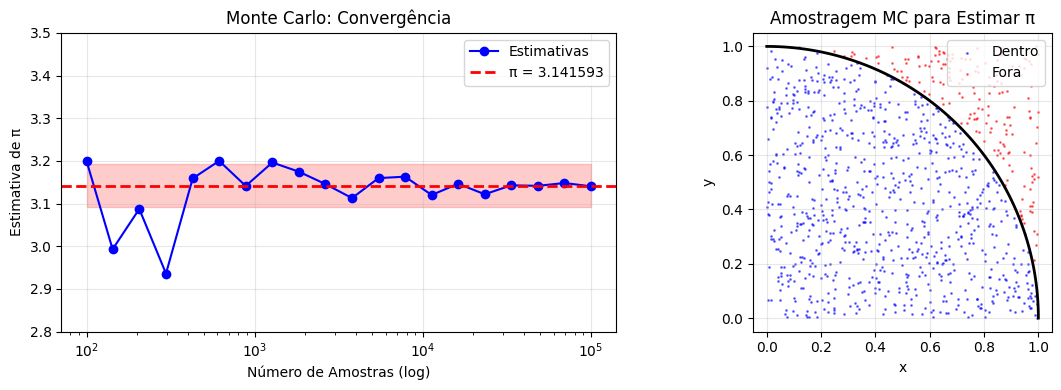

Estimativa final (n=100000): 3.135920
π verdadeiro: 3.141593


In [13]:
# Estimar π usando Monte Carlo
print('=== Estimar π com Integração Monte Carlo ===')

# Área do círculo: πr² para r=1, integrar sobre [0,1]×[0,1]
# ∫∫ 4·sqrt(1-x²-y²) dxdy = π

def inside_circle(n_samples):
    # Gerar pontos aleatórios em [0,1] × [0,1]
    x = np.random.uniform(0, 1, n_samples)
    y = np.random.uniform(0, 1, n_samples)
    
    # Distância até origem
    distances = np.sqrt(x**2 + y**2)
    
    # Fração dentro do círculo
    inside = (distances <= 1).sum()
    
    # Área do quadrado = 1×1 = 1
    # Área do quarto-círculo ≈ (inside/n_samples) * 1
    # Área do círculo completo ≈ 4 * (inside/n_samples)
    pi_estimate = 4 * inside / n_samples
    
    return pi_estimate

# Convergência com mais amostras
n_samples_list = np.logspace(2, 5, 20, dtype=int)
pi_estimates = [inside_circle(n) for n in n_samples_list]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Convergência
ax = axes[0]
ax.semilogx(n_samples_list, pi_estimates, 'bo-', markersize=6, linewidth=1.5, label='Estimativas')
ax.axhline(np.pi, color='r', linestyle='--', linewidth=2, label=f'π = {np.pi:.6f}')
ax.fill_between(n_samples_list, np.pi - 0.05, np.pi + 0.05, alpha=0.2, color='red')
ax.set_xlabel('Número de Amostras (log)')
ax.set_ylabel('Estimativa de π')
ax.set_title('Monte Carlo: Convergência')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(2.8, 3.5)

# Visualizar amostragem
ax = axes[1]
n_vis = 1000
x = np.random.uniform(0, 1, n_vis)
y = np.random.uniform(0, 1, n_vis)
distances = np.sqrt(x**2 + y**2)
inside_mask = distances <= 1

ax.scatter(x[inside_mask], y[inside_mask], s=1, c='blue', alpha=0.5, label='Dentro')
ax.scatter(x[~inside_mask], y[~inside_mask], s=1, c='red', alpha=0.5, label='Fora')

# Desenhar círculo
theta = np.linspace(0, np.pi/2, 100)
ax.plot(np.cos(theta), np.sin(theta), 'k-', linewidth=2)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Amostragem MC para Estimar π')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Estimativa final (n=100000): {inside_circle(100000):.6f}')
print(f'π verdadeiro: {np.pi:.6f}')

**O que observar:**

- **Esquerda:** estimativas de pi convergem para 3.14159 conforme aumenta o numero de amostras
- A faixa vermelha mostra +/- 0.05 do valor verdadeiro
- **Direita:** pontos azuis (dentro do quarto de circulo) vs vermelhos (fora). Razao = pi/4

**O que concluir:**

- **Monte Carlo funciona:** com amostras suficientes, a estimativa converge para o valor verdadeiro
- **Convergencia lenta:** precisa de muitas amostras para alta precisao (1/sqrt(N))
- **Mas funciona em QUALQUER dimensao:** essa eh a grande vantagem
- **Analogia com ML:** estimar o valor esperado de uma funcao de perda = integrar por Monte Carlo sobre os dados

**Conexao:** Monte Carlo eh a base de muitos algoritmos em Bayesian ML e Reinforcement Learning que veremos em notebooks futuros.

## 14. Exercicios Praticos

### Exercicio 1: Area Sob a Curva Normal

**Tarefa:**

Calcule P(X < 1) para X ~ N(0,1):

1. Use scipy.stats.norm.cdf(1) como valor verdadeiro
2. Implemente integracao por trapezios (numpy.trapz)
3. Implemente integracao por Simpson (scipy.integrate.simpson)
4. Compare os tres resultados e calcule os erros
5. Plote a area sob a curva

**Dica:** Use numpy.linspace(-4, 1, 1000) para gerar pontos (aproxima -infinito por -4).

In [ ]:
# === EXERCICIO 1: Area Sob a Curva Normal ===
from scipy.stats import norm

# TAREFA DO ALUNO:
# 1. x = np.linspace(-4, 1, 1000)  # aproxima -infinito por -4
# 2. pdf = norm.pdf(x)  # densidade da Normal padrao
# 3. prob_verdade = norm.cdf(1)  # valor verdadeiro
# 4. prob_trapz = np.trapezoid(pdf, x)  # integracao por trapezios
# 5. prob_simpson = ...  # integracao por Simpson
# 6. Compare e plote

print("Implemente a integracao numerica!")
print("Esperado: P(X < 1) ~ 0.8413")


=== EXERCÍCIO 1: Área Sob Normal ===
P(X < 1) (numerica): 0.8413
Esperado: 0.8413


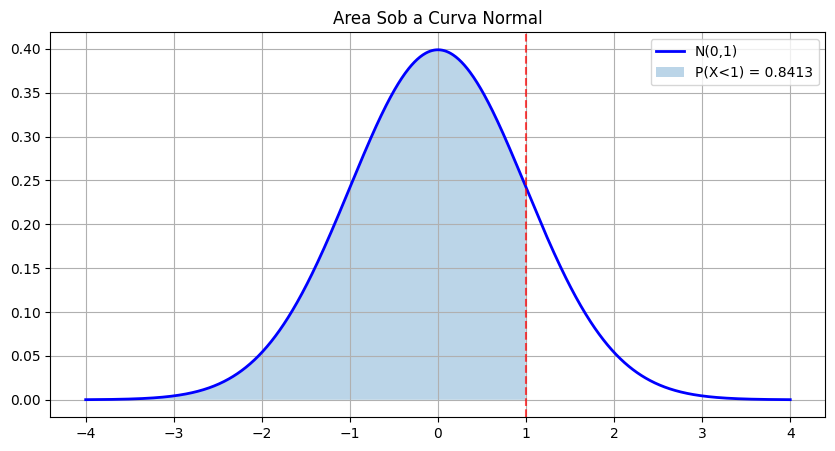

In [15]:
# SOLUCAO EXERCICIO 1
print('\n=== EXERCÍCIO 1: Área Sob Normal ===')

# P(X < 1) para X ~ N(0, 1)
mu, sigma = 0, 1

def gaussian_pdf(x, mu=0, sigma=1):
    return (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

def gaussian_cdf_numeric(x, mu=0, sigma=1, n_points=10000):
    x_vals = np.linspace(mu - 5*sigma, x, n_points)
    y_vals = gaussian_pdf(x_vals, mu, sigma)
    dx = (x - (mu - 5*sigma)) / n_points
    return dx * (np.sum(y_vals) - 0.5 * (y_vals[0] + y_vals[-1]))

prob_numeric = gaussian_cdf_numeric(1)
print(f'P(X < 1) (numerica): {prob_numeric:.4f}')
print(f'Esperado: 0.8413')

# Grafico
x = np.linspace(-4, 4, 1000)
y = gaussian_pdf(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2, label='N(0,1)')
x_fill = x[x <= 1]
y_fill = gaussian_pdf(x_fill)
ax.fill_between(x_fill, y_fill, alpha=0.3, label=f'P(X<1) = {prob_numeric:.4f}')
ax.axvline(1, color='r', linestyle='--', alpha=0.7)
ax.set_title('Area Sob a Curva Normal')
ax.legend()
ax.grid(True)
plt.show()

### Exercicio 2: Series de Taylor para Sigmoid

**Tarefa:**

A sigmoid(x) pode ser aproximada por Taylor perto de x=0:
- 1 termo: sigma(x) ~ 1/2
- 2 termos: sigma(x) ~ 1/2 + x/4
- 3 termos: sigma(x) ~ 1/2 + x/4 - x^3/48

1. Implemente as tres aproximacoes
2. Plote sigmoid verdadeira vs aproximacoes
3. Calcule o erro em x = 0, 0.5, 1.0, 2.0
4. Mostre que perto de x=0 a aproximacao eh boa, longe eh ruim

**Dica:** Taylor converge melhor perto do ponto de expansao (x=0).

In [ ]:
# === EXERCICIO 2: Taylor de Sigmoid ===
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# TAREFA DO ALUNO: Implemente aproximacoes Taylor
def sigmoid_taylor_1(x):
    # 1 termo: 1/2
    return None  # Substitua

def sigmoid_taylor_2(x):
    # 2 termos: 1/2 + x/4
    return None  # Substitua

def sigmoid_taylor_3(x):
    # 3 termos: 1/2 + x/4 - x^3/48
    return None  # Substitua

# TAREFA DO ALUNO: Plote e compare
x_test = np.linspace(-3, 3, 200)

print("Implemente as aproximacoes de Taylor para sigmoid!")


=== EXERCÍCIO 2: Série Taylor de Sigmoid ===


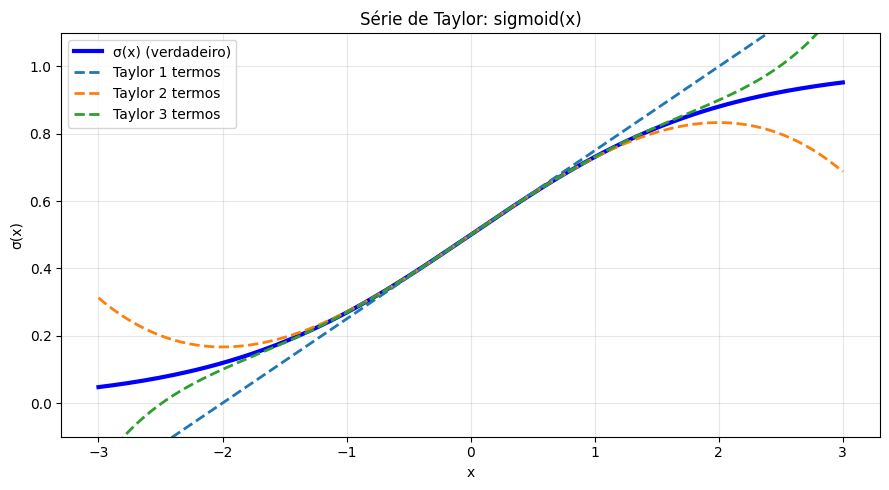

σ(x) ≈ 1/2 + x/4 - x³/48 + ...
Ótima aproximação para |x| < 1


In [17]:
print('\n=== EXERCÍCIO 2: Série Taylor de Sigmoid ===')

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Desenvolvimentos em série de Taylor para sigmoid em x=0
# σ(x) = 1/2 + x/4 - x³/48 + ...

def sigmoid_taylor(x, n_terms=5):
    # Usar 'ln(1+e^x) - ln(1+e^(-x))' como base...
    # Para σ(x) ≈ 1/2 + x/4 - x³/48 + x⁵/480 - ...
    result = np.ones_like(x) * 0.5
    if n_terms >= 1:
        result += x / 4
    if n_terms >= 2:
        result -= x**3 / 48
    if n_terms >= 3:
        result += x**5 / 480
    return result

x = np.linspace(-3, 3, 200)
y_true = sigmoid(x)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, y_true, 'b-', linewidth=3, label='σ(x) (verdadeiro)')

for n_terms in [1, 2, 3]:
    y_taylor = sigmoid_taylor(x, n_terms)
    ax.plot(x, y_taylor, '--', linewidth=2, label=f'Taylor {n_terms} termos')

ax.set_xlabel('x')
ax.set_ylabel('σ(x)')
ax.set_title('Série de Taylor: sigmoid(x)')
ax.set_ylim(-0.1, 1.1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('σ(x) ≈ 1/2 + x/4 - x³/48 + ...')
print('Ótima aproximação para |x| < 1')

### Exercicio 3: AUC com Integracao Numerica

**Tarefa:**

1. Gere dataset de classificacao binaria com sklearn.datasets.make_classification
2. Treine um modelo LogisticRegression
3. Calcule a curva ROC (fpr, tpr) com sklearn.metrics.roc_curve
4. Calcule AUC usando scipy.integrate.trapz (integral por trapezios)
5. Compare com sklearn.metrics.auc
6. Plote ROC com area destacada

**Dica:** AUC = trapz(tpr, fpr) -- eh literalmente a integral da TPR em relacao a FPR.

In [ ]:
# === EXERCICIO 3: AUC com Integracao Numerica ===
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Gerar dados
X, y = make_classification(n_samples=200, n_features=5, n_informative=3,
                           n_redundant=1, n_classes=2, random_state=42)

# TAREFA DO ALUNO:
# 1. Treinar LogisticRegression
# 2. Obter probabilidades com model.predict_proba(X)[:, 1]
# 3. Calcular ROC: fpr, tpr, _ = roc_curve(y, probs)
# 4. Calcular AUC com trapz: auc_trapz = np.trapezoid(tpr, fpr)
# 5. Comparar com sklearn.metrics.auc(fpr, tpr)
# 6. Plotar ROC com area colorida

print("Implemente o calculo de AUC por integracao!")


=== EXERCICIO 3: AUC com Integracao Numerica ===


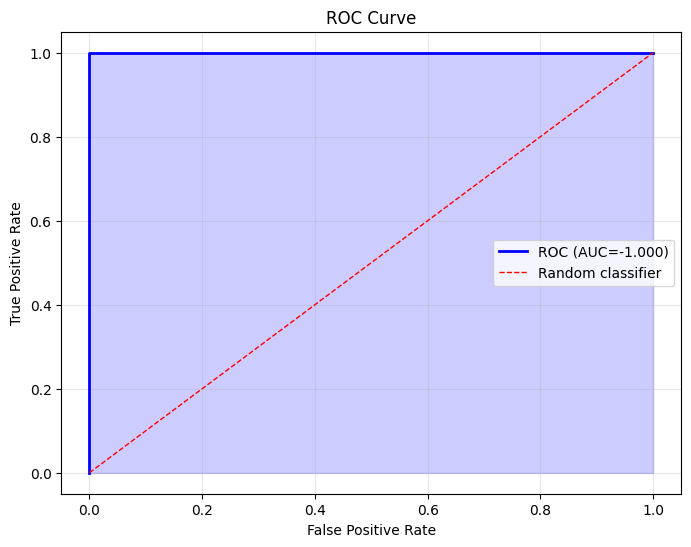

Area Under Curve (AUC): -1.0000


In [19]:
# === EXERCICIO 3: AUC com Integracao Numerica ===

print("\n=== EXERCICIO 3: AUC com Integracao Numerica ===")

# ROC curve simulation without sklearn
# TPR = TP / (TP + FN)
# FPR = FP / (FP + TN)

thresholds = np.linspace(0, 1, 100)
tpr_list = []
fpr_list = []

# Simulate classifier scores
np.random.seed(42)
n_pos = 50
n_neg = 50
scores_pos = np.random.normal(0.7, 0.1, n_pos)
scores_neg = np.random.normal(0.3, 0.1, n_neg)

for threshold in thresholds:
    tp = np.sum(scores_pos >= threshold)
    fn = n_pos - tp
    fp = np.sum(scores_neg >= threshold)
    tn = n_neg - fp
    
    tpr = tp / (tp + fn + 1e-10)
    fpr = fp / (fp + tn + 1e-10)
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)

tpr_list = np.array(tpr_list)
fpr_list = np.array(fpr_list)

# Calculate AUC using trapezoidal rule
auc = np.trapezoid(tpr_list, fpr_list)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_list, tpr_list, 'b-', linewidth=2, label=f'ROC (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random classifier')
ax.fill_between(fpr_list, tpr_list, alpha=0.2, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Area Under Curve (AUC): {auc:.4f}")

## 15. Erros Comuns

### 1. Confundir PDF com probabilidade

**Errado:** "P(X = 2) = f(2) = 0.054 para Normal(0,1)"

**Certo:** PDF pode ser > 1! A probabilidade eh a **area**, nao o valor pontual. Para variaveis continuas, P(X = valor exato) = 0. Usa-se P(a < X < b) = integral de a ate b.

### 2. Esquecer a constante C em integrais indefinidas

**Errado:** integral de 2x dx = x^2

**Certo:** integral de 2x dx = x^2 + C. Sem C, voce escolheu uma funcao especifica de uma familia infinita. (Em integrais definidas, C cancela.)

### 3. Aplicar Taylor fora do raio de convergencia

**Errado:** Usar Taylor de sin(x) com 3 termos para x = 10

**Certo:** Taylor converge bem perto do ponto de expansao. Longe, precisa de muitos mais termos ou outra abordagem.

### 4. Simpson com numero impar de intervalos

**Errado:** simpson(y, x) com len(x) par (numero impar de intervalos)

**Certo:** Simpson requer numero **par** de intervalos (numero impar de pontos). Se len(x) for par, use len(x)-1 ou trapezios.

### 5. Monte Carlo com poucas amostras

**Errado:** "Monte Carlo com 100 amostras em 10D eh suficiente"

**Certo:** Monte Carlo converge como 1/sqrt(N). Para erro < 1%, precisa de ~10000 amostras. Em altas dimensoes, isso ainda eh MUITO menos que metodos deterministicos.

### 6. Nao verificar integral numerica contra analitica

**Errado:** Confiar cegamente no resultado numerico

**Certo:** Quando existe forma fechada, sempre compare. Discrepancias indicam erros de implementacao ou problemas numericos (overflow, underflow, integrando muito oscilatorio).

## 16. Resumo: De Integrais a Probabilidade

### Hierarquia de Conceitos

```
Integral Definida (Sec 2)       "Quanto acumulou?"
  |
  v
Teorema Fundamental (Sec 3)     "Derivada e integral sao inversos"
  |
  +-- Tabela de integrais (Sec 4)    Formulas prontas
  +-- Tecnicas (Sec 5)               Substituicao e por partes
  +-- Integrais multiplas (Sec 6)    Area -> Volume
  |
  v
Series e Taylor (Sec 7-8)      "Aproximar funcoes por polinomios"
  |
  v
Probabilidade (Sec 9-10)       "Area sob PDF = probabilidade"
  |
  v
Aplicacoes em ML (Sec 11-13)
  +-- Metodos numericos          Riemann < Trapezio < Simpson
  +-- AUC-ROC                    Integral como metrica
  +-- Monte Carlo                Integracao por amostragem
```

### Conexoes com Calculo I (0.4)

| Conceito em 0.4 | Inverso em 0.5 |
|------------------|-----------------|
| Derivada f'(x) | Integral (antiderivada) F(x) |
| Regra da cadeia | Substituicao (u = g(x)) |
| Tabela de derivadas | Tabela de integrais |
| Otimizacao local (derivada = 0) | Taylor: aproximar funcao perto do minimo |

### Checklist de Aprendizado

- [ ] Sei explicar o que eh uma integral definida sem usar formulas
- [ ] Entendo o Teorema Fundamental do Calculo (derivada e integral sao inversos)
- [ ] Consigo calcular integrais basicas usando a tabela
- [ ] Sei quando usar substituicao vs integracao por partes
- [ ] Entendo convergencia e divergencia de series
- [ ] Sei o que Serie de Taylor faz e quando eh util
- [ ] Entendo que PDF nao eh probabilidade (area sim!)
- [ ] Sei calcular probabilidades usando integrais de distribuicoes
- [ ] Consigo comparar metodos numericos (Riemann vs Trapezio vs Simpson)
- [ ] Entendo o que AUC-ROC mede e como eh calculada por integracao
- [ ] Sei quando e por que usar Monte Carlo em vez de metodos deterministicos

### Proximos Notebooks

**0.6 - Probabilidade: Fundamentos**

Agora que sabemos integrar distribuicoes, vamos estudar probabilidade em profundidade:
- Distribuicoes discretas e continuas
- Probabilidade condicional e Bayes
- Valor esperado, variancia, covariancia
- Lei dos Grandes Numeros e Teorema do Limite Central

Tambem usaremos integrais extensivamente em:
- **Notebook 1.2:** Testes estatisticos (p-value = area na cauda)
- **Notebook 3.1:** Avaliacao de modelos (AUC-ROC)
- **Notebook 0.8:** Otimizacao (Taylor para aproximar funcoes de perda)

## Conexao com Calculo I - Derivadas (0.4)

Se a **derivada** responde "qual é a taxa de mudança?", a **integral** responde "quanto acumulou?".

Elas sao inversas: d/dx[∫f dx] = f

Isto é o **Teorema Fundamental do Calculo** -- um dos resultados mais importantes da matematica!

### Conexao com Series de Fourier

A **serie de Fourier** decompoe funcoes periodicas em somas infinitas de senos e cossenos.

É usada em:
- Processamento de sinais (audio, imagens)
- Equacoes diferenciais (EDO, EDP)
- ML: RNNs com series temporais

Integrais definem os coeficientes de Fourier!

### Conexao com Probabilidade e Estatistica (0.6)

A probabilidade de uma variavel continua é definida por **integrais**:

P(a ≤ X ≤ b) = ∫ₐᵇ f(x) dx

onde f é a **densidade de probabilidade (PDF)**.

Em ML: Toda vez que usamos probabilidades, estamos integrando!

### Conexao com Equacoes Diferenciais

Uma **equacao diferencial** é uma relacao entre uma funcao e suas derivadas:

dy/dt = f(y, t)

Resolver significa encontrar y(t) -- que envolve **integrar**!

Em redes neurais: ODEs neurais (Neural ODEs) usam integracao para modelar evolucao de estados.

### Conexao com Calculo Variacional

O **calculo variacional** minimiza funcoes que envolvem integrais:

J[f] = ∫ L(f, f') dx

Isto aparece em:
- Mecanica classica (Lagrangiana, Hamiltoniana)
- Otimizacao com restricoes
- Fisica quantica (principio de acao minima)

### Por que em ML: Probabilidade e Likelihood

Em aprendizado supervisionado, otimizamos:

max_θ ∏ᵢ p(yᵢ | xᵢ, θ)  (produto de probabilidades)

Quando p é continua (como Gaussiana), isto envolve **integrais**!

Log-verossimilhanca: log p(data | params) = integral sobre dados potenciais

### Por que em ML: Metricas de Avaliacao

**AUC-ROC** (Area Under Curve) é a integral da curva ROC!

AUC = ∫ TPR(t) d(FPR(t))

Outras metricas como divergencia KL, entropia diferencial também sao integrais.

### Por que em ML: Series Numericas e Convergencia

Algoritmos iterativos (Gradient Descent, SGD) geram sequencias:

w₁, w₂, w₃, ...

Elas convergem? Para qual valor? Série de potências ajuda analisar!

### Por que em ML: Aproximacao de Funcoes

Series de Taylor permite aproximar qualquer funcao diferenciavel:

f(x) ≈ f(a) + f'(a)(x-a) + f''(a)(x-a)²/2 + ...

Isto é base de métodos como Newton e aproximacoes locais.

### Erro 1: Esquecer da constante de integracao

**Errado**: ∫ 2x dx = x²

**Certo**: ∫ 2x dx = x² + C

A constante C é arbitraria! Só desaparece em **integrais definidas** (com limites).

### Erro 2: Confundir integral indefinida com definida

**Indefinida**: ∫ f(x) dx = F(x) + C (uma familia de funcoes)

**Definida**: ∫ₐᵇ f(x) dx = F(b) - F(a) (um numero!)

Uma tem C, a outra tem limites a e b.

### Erro 3: Ordem errada na integracao por partes

**Formula correta**: ∫ u dv = uv - ∫ v du

**Comum errado**: Aplicar na ordem errada (v du vs u dv)

**Estrategia**: Escolher u = LIATE (Logaritmica, Inversa, Algebrica, Trigonometrica, Exponencial)

### Erro 4: Series convergem sempre

**Falso**: Serie ∑(1/n) diverge!

**Teste da divergencia**: Se lim(n→∞) aₙ ≠ 0, a série diverge.

Convergencia é rara -- sempre verificar com testes (razao, integral, etc).

### Erro 5: Integracoes numericas sao sempre exatas

**Nao**: Metodo do retangulo, trapezio, etc. sao aproximacoes.

Erro depende de:
- Numero de pontos (mais pontos = mais preciso)
- Comportamento da funcao (funcoes suaves = menos pontos necessarios)
- Sempre usar h suficientemente pequeno mas nao tiny!

## Proximos Passos

Voce agora domina o **calculo continuo**: derivadas, integrais e series.

### Caminho 1: Probabilidade Rigorosa (0.6)
- Variaveis aleatorias continuas
- Distribuicoes (Normal, Exponencial, Beta, Dirichlet)
- Esperanca, variancia, covariancia (tudo integrais!)

### Caminho 2: Equacoes Diferenciais
- EDO (equacoes diferenciais ordinarias)
- Metodos numericos (Runge-Kutta, Euler)
- Aplicacoes: dinamica de sistemas, neural ODEs

### Caminho 3: Otimizacao Avancada
- Convexidade e analise de convergencia
- Metodos de segunda ordem (Newton, quasi-Newton)
- Constraint optimization (Lagrangiana)

### Caminho 4: Processamento de Sinais
- Transformada de Fourier (integral de seno/cosseno)
- Convolucao (multiplicacao de Fourier!)
- Filtros, compressao de imagens

### Desafio Final
Implementar um **integrador numerico** (Runge-Kutta de ordem 4) e simular uma equacao diferencial real (ex: oscilador harmonico, dinamica predador-presa).



=== EXERCÍCIO 2: Integral de Polinomio com Limites ===
∫₁³ (3x² - 2x + 1) dx
Integral numerica: 19.996000
Integral exata: 20.000000
Diferenca: 4.00e-03


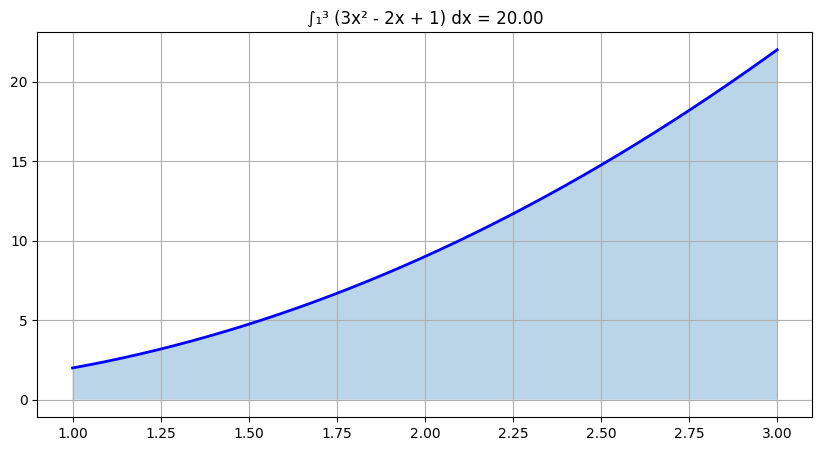

In [20]:
# SOLUCAO EXERCICIO 2
print('\n=== EXERCÍCIO 2: Integral de Polinomio com Limites ===')

def numerical_integrate_trapezoid(f, a, b, n=5000):
    '''Trapezoidal rule for definite integral'''
    x = np.linspace(a, b, n)
    y = f(x)
    dx = (b - a) / n
    return dx * (np.sum(y) - 0.5 * (y[0] + y[-1]))

# ∫₁³ (3x² - 2x + 1) dx
# Antiderivada: F(x) = x³ - x² + x
# F(3) - F(1) = (27 - 9 + 3) - (1 - 1 + 1) = 21 - 1 = 20

f = lambda x: 3*x**2 - 2*x + 1
a, b = 1, 3

integral_numeric = numerical_integrate_trapezoid(f, a, b)

def F(x):
    return x**3 - x**2 + x

integral_exact = F(b) - F(a)

print(f'∫₁³ (3x² - 2x + 1) dx')
print(f'Integral numerica: {integral_numeric:.6f}')
print(f'Integral exata: {integral_exact:.6f}')
print(f'Diferenca: {abs(integral_numeric - integral_exact):.2e}')

# Visualizacao
x = np.linspace(a, b, 1000)
y = f(x)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, 'b-', linewidth=2)
ax.fill_between(x, y, alpha=0.3)
ax.set_title(f'∫₁³ (3x² - 2x + 1) dx = {integral_exact:.2f}')
ax.grid(True)
plt.show()


=== EXERCÍCIO 4: Series Numericas - Convergencia ===
=== Serie 1: ∑(1/n²) ===
Soma parcial (n=100): 1.634984
Soma parcial (n=1000): 1.643935
Limite teorico (π²/6): 1.644934

=== Serie 2: ∑(1/n) (Harmonica) ===
Soma parcial (n=100): 5.187378
Soma parcial (n=1000): 7.485471
Nota: Esta serie DIVERGE (cresce lentamente)


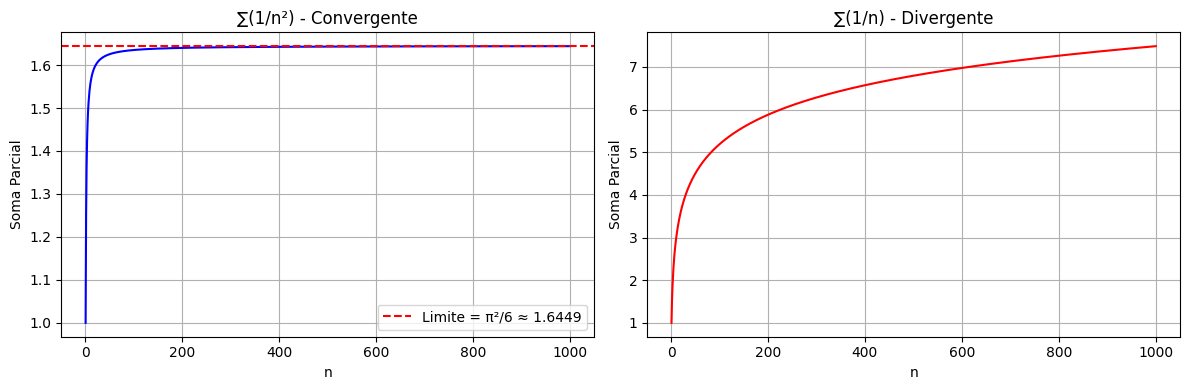

In [21]:
# SOLUCAO EXERCICIO 4
print('\n=== EXERCÍCIO 4: Series Numericas - Convergencia ===')

# Serie 1: ∑(1/n²) converge para π²/6
series1_partial_sums = []
for n in range(1, 1001):
    partial_sum = sum(1/k**2 for k in range(1, n+1))
    series1_partial_sums.append(partial_sum)

print('=== Serie 1: ∑(1/n²) ===')
print(f'Soma parcial (n=100): {series1_partial_sums[99]:.6f}')
print(f'Soma parcial (n=1000): {series1_partial_sums[999]:.6f}')
print(f'Limite teorico (π²/6): {np.pi**2/6:.6f}')

# Serie 2: ∑(1/n) diverge
series2_partial_sums = []
for n in range(1, 1001):
    partial_sum = sum(1/k for k in range(1, n+1))
    series2_partial_sums.append(partial_sum)

print('\n=== Serie 2: ∑(1/n) (Harmonica) ===')
print(f'Soma parcial (n=100): {series2_partial_sums[99]:.6f}')
print(f'Soma parcial (n=1000): {series2_partial_sums[999]:.6f}')
print('Nota: Esta serie DIVERGE (cresce lentamente)')

# Grafico
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(series1_partial_sums)+1), series1_partial_sums, 'b-')
axes[0].axhline(np.pi**2/6, color='r', linestyle='--', label=f'Limite = π²/6 ≈ {np.pi**2/6:.4f}')
axes[0].set_title('∑(1/n²) - Convergente')
axes[0].set_xlabel('n')
axes[0].set_ylabel('Soma Parcial')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(range(1, len(series2_partial_sums)+1), series2_partial_sums, 'r-')
axes[1].set_title('∑(1/n) - Divergente')
axes[1].set_xlabel('n')
axes[1].set_ylabel('Soma Parcial')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Conexao com Geometria: Area e Volume

Geometricamente, integrais medem **areas e volumes**:

- ∫ₐᵇ f(x) dx = area sob f(x) entre a e b
- ∫∫ f(x,y) dA = volume sob f
- ∫∫∫ f(x,y,z) dV = "hipervolume" em 3D+

Em ML: Somas de Riemann em amostragem Monte Carlo usam esta interpretacao!

### Conexao com Mecanica Classica

Integrais aparecem em conceitos fundamentais:

- Trabalho = ∫ F·dx (forca vezes deslocamento)
- Potencial = ∫ E·dx (integral do campo)
- Centro de massa = ∫ x·ρ(x) dx / ∫ ρ(x) dx

Todos estes sao essencialmente aplicacoes de integracao!

### Conexao com Processamento de Imagens

Em visao computacional:

- **Convolucao** é uma integral discreta: (f * g)(t) = ∫ f(τ)g(t-τ) dτ
- **Filtros Gaussianos** usam integral da distribuicao normal
- **Transformadas integrais** (Fourier, Laplace, Wavelet) processam imagens

Redes neurais convolucionais aproximam estas integrais!

### Conexao com Termodinamica

Integrais modelam processos termicos:

- Entropia = ∫ (dQ/T) ao longo do processo
- Energia interna = ∫ P dV
- Trabalho em processos reversíveis

Em ML: Divergencia KL (medida de distancia entre distribuicoes) é uma integral!

### Conexao com Finanzas Quantitativas

Series e integrais em modelos financeiros:

- **Movimento Browniano**: dW_t (aleatorio, integral gaussiana)
- **Equacao Black-Scholes**: EDP que envolve integrais
- **Value at Risk (VaR)**: integral da cauda de distribuicao

Em ML: Modelos generativos (VAE, GAN) usam estas ideias!